# 오차 분석

교차검증 결과를 열어서 어디서 왜 틀리는지 본다.

대상은 `zerophase-smooth` 특징 표에 catboost 를 붙인 실행이다.
앙상블이 0.17%p 높지만 여러 모델의 확률을 평균한 것이라 판단 근거를 캘 수 없다.

그림의 축 이름은 영어로 둔다. 서버에 한글 글꼴이 없으면 네모로 깨진다.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

ROOT = Path.cwd().parent
STAGES = ["W", "LS", "DS", "R"]

# 대표 실행을 조건으로 고른다. 여러 개가 잡히면 조용히 엉뚱한 것을 보게 되므로 멈춘다.
found = sorted(ROOT.glob("runs/catboost/zerophase-expanding-smooth/cw-balanced/*/metrics.json"))
assert len(found) == 1, f"실행이 {len(found)}개입니다: {[str(f.parent) for f in found]}"
run = found[0].parent

pred = pd.read_parquet(run / "predictions.parquet")

pd.Series(json.loads((run / "metrics.json").read_text())["pooled"]).round(3)

macro_f1    0.839
accuracy    0.872
kappa       0.800
f1_W        0.925
f1_LS       0.873
f1_DS       0.805
f1_R        0.753
dtype: float64

## 어디서 틀리나

클래스별 F1 은 DS 와 R 이 낮다는 것까지만 알려준다.
틀린 것이 **어느 클래스로** 새는지는 혼동행렬을 봐야 안다.

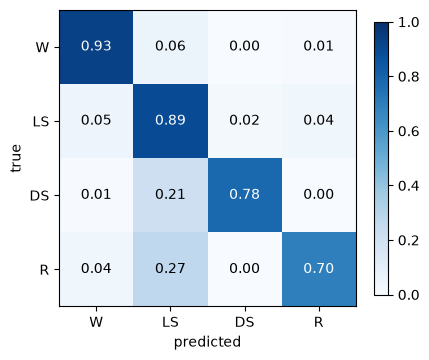

In [2]:
cm = confusion_matrix(pred["stage"], pred["pred"], labels=range(4), normalize="true")

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(4), STAGES)
ax.set_yticks(range(4), STAGES)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
for i in range(4):
    for j in range(4):
        ax.text(
            j,
            i,
            f"{cm[i, j]:.2f}",
            ha="center",
            va="center",
            color="white" if cm[i, j] > 0.5 else "black",
        )
fig.colorbar(im, shrink=0.8)
fig.tight_layout()

In [3]:
off = [(STAGES[i], STAGES[j], cm[i, j]) for i in range(4) for j in range(4) if i != j]
pd.DataFrame(off, columns=["true", "predicted", "rate"]).sort_values("rate", ascending=False).head(
    5
)

,true,predicted,rate
10,R,LS,0.267467
7,DS,LS,0.212746
0,W,LS,0.059715
3,LS,W,0.048834
5,LS,R,0.038090


## R 이 LS 로 새는 순간은 언제인가

단계가 바뀌는 경계 근처에서만 틀린다면 라벨 자체가 애매한 지점이라는 뜻이다.
경계와 상관없이 틀린다면 특징이 REM 을 못 담고 있다는 뜻이다.

각 에포크가 같은 단계가 이어지는 구간의 가장자리에서 몇 칸 안쪽인지를 센다.
0 이면 구간의 첫 칸이거나 마지막 칸이다.


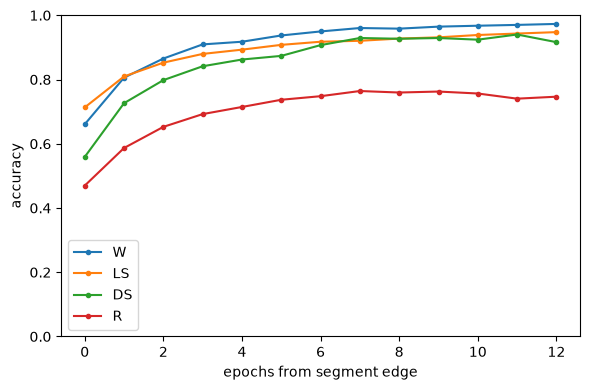

In [4]:
def edge_distance(stage):
    seg = np.cumsum(np.r_[0, np.diff(stage) != 0])
    out = np.empty(len(stage), dtype=int)
    for s in np.unique(seg):
        m = seg == s
        pos = np.arange(m.sum())
        out[m] = np.minimum(pos, m.sum() - 1 - pos)
    return out


pred = pred.sort_values(["subject", "night", "epoch_idx"]).reset_index(drop=True)
pred["edge_dist"] = np.concatenate(
    [
        edge_distance(g["stage"].to_numpy())
        for _, g in pred.groupby(["subject", "night"], sort=False)
    ]
)
pred["correct"] = pred["stage"] == pred["pred"]

acc = pred[pred["edge_dist"] <= 12].groupby(["stage", "edge_dist"])["correct"].mean().unstack(0)

fig, ax = plt.subplots(figsize=(6, 4))
for i, name in enumerate(STAGES):
    ax.plot(acc.index, acc[i], marker="o", ms=3, label=name)
ax.set_xlabel("epochs from segment edge")
ax.set_ylabel("accuracy")
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()

구간 길이가 짧으면 가장자리 근처 에포크의 비중이 커진다. 단계마다 구간이 얼마나 긴지 같이 본다.

In [5]:
seg_ids, offset = [], 0
for _, g in pred.groupby(["subject", "night"], sort=False):
    s = np.cumsum(np.r_[0, np.diff(g["stage"].to_numpy()) != 0]) + offset
    seg_ids.append(s)
    offset = s[-1] + 1
pred["segment"] = np.concatenate(seg_ids)

lengths = pred.groupby("segment", sort=False).agg(stage=("stage", "first"), n=("stage", "size"))
lengths.groupby("stage")["n"].describe()[["count", "50%", "mean"]].set_axis(STAGES)

,count,50%,mean
W,3694.0,2.0,17.843259
LS,7030.0,4.0,12.895306
DS,2659.0,1.0,4.903723
R,1525.0,11.0,16.940984


틀린 REM 에포크에서 모델이 얼마나 확신했는지 본다.
확신 없이 틀렸다면 특징이 부족한 것이고, 확신하며 틀렸다면 특징이 REM 을 LS 처럼 보이게 만들고 있다는 뜻이다.

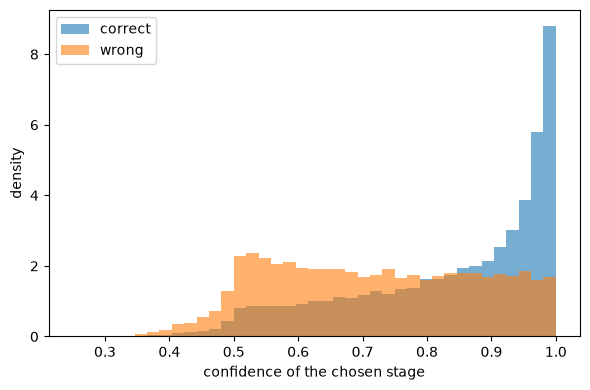

In [6]:
rem = pred[pred["stage"] == 3]
conf = rem[[f"proba_{s}" for s in STAGES]].max(axis=1)

fig, ax = plt.subplots(figsize=(6, 4))
bins = np.linspace(0.25, 1, 40)
ax.hist(conf[rem["correct"]], bins=bins, alpha=0.6, density=True, label="correct")
ax.hist(conf[~rem["correct"]], bins=bins, alpha=0.6, density=True, label="wrong")
ax.set_xlabel("confidence of the chosen stage")
ax.set_ylabel("density")
ax.legend()
fig.tight_layout()

## DS 는 왜 조각나 있나

앞의 구간 길이는 예측 파일에서 잰 것이라, 판독불가로 빠진 에포크가 구간을 갈랐을 수 있다.
원본 라벨에서 에포크 번호가 실제로 이어지는지까지 보고 다시 잰다.


In [7]:
rows = []
for f in sorted((ROOT / "data/interim/epochs").glob("*.npz")):
    z = np.load(f, allow_pickle=False)
    lo, hi = int(z["crop_lo"]), int(z["crop_hi"])
    idx, lab = z["epoch_idx"], z["labels"]
    keep = (idx >= lo) & (idx < hi)
    idx, lab = idx[keep], lab[keep]
    seg = np.cumsum(np.r_[0, (np.diff(lab) != 0) | (np.diff(idx) != 1)])
    first = np.flatnonzero(np.r_[True, np.diff(seg) != 0])
    rows += list(zip(lab[first], np.diff(np.r_[first, len(seg)]), strict=True))

raw = pd.DataFrame(rows, columns=["stage", "n"])
share = (
    raw.assign(epochs=raw["n"])
    .groupby("stage")
    .apply(
        lambda g: pd.Series(
            {
                "구간 수": len(g),
                "구간 길이 중앙값": g["n"].median(),
                "1칸 구간 비율": (g["n"] == 1).mean(),
                "에포크의 몇 %가 3칸 이하 구간에 있나": g.loc[g["n"] <= 3, "n"].sum()
                / g["n"].sum(),
            }
        ),
        include_groups=False,
    )
)
share.set_axis(STAGES).round(3)

,구간 수,구간 길이 중앙값,1칸 구간 비율,에포크의 몇 %가 3칸 이하 구간에 있나
W,3693.0,2.0,0.384,0.054
LS,7081.0,4.0,0.278,0.061
DS,2663.0,1.0,0.533,0.219
R,1560.0,10.0,0.095,0.027


조각화가 사실이라면, 짧은 구간일수록 못 맞혀야 한다. 구간 길이별 정확도를 본다.

정확도                       에포크 수                    
             W     LS     DS      R      W     LS    DS      R
seg_len                                                       
1        0.525  0.584  0.438  0.288   1420   1954  1417    146
2-3      0.611  0.654  0.557  0.369   2102   3540  1437    539
4-7      0.719  0.757  0.687  0.568   2422   5326  1404   1316
8-15     0.829  0.842  0.778  0.674   2986   9826  1434   3699
16+      0.969  0.928  0.911  0.719  56983  70008  7347  20135

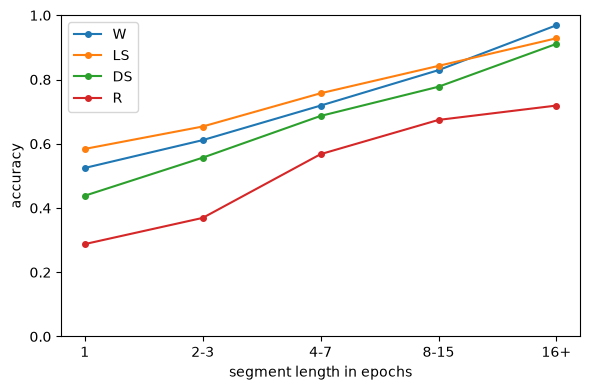

In [8]:
pred["seg_len"] = pred["segment"].map(lengths["n"])
band = pd.cut(pred["seg_len"], [0, 1, 3, 7, 15, 10**6], labels=["1", "2-3", "4-7", "8-15", "16+"])

by_len = (
    pred.groupby([band, "stage"], observed=True)["correct"]
    .mean()
    .unstack("stage")
    .set_axis(STAGES, axis=1)
)
n_ep = pred.groupby([band, "stage"], observed=True).size().unstack("stage").set_axis(STAGES, axis=1)

fig, ax = plt.subplots(figsize=(6, 4))
for name in STAGES:
    ax.plot(by_len.index.astype(str), by_len[name], marker="o", ms=4, label=name)
ax.set_xlabel("segment length in epochs")
ax.set_ylabel("accuracy")
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()

pd.concat({"정확도": by_len.round(3), "에포크 수": n_ep}, axis=1)

여기까지의 결론.

- DS 오답의 절반이 3칸 이하 구간에서 나온다. 그 구간에 DS 에포크의 22% 가 몰려 있다.
  긴 구간에서는 0.911 로 LS 와 비슷하다. DS 가 약한 것은 짧게 스치듯 나타나기 때문이다.
- R 은 다르다. 16칸 이상 긴 구간에서도 0.719 로 꼴찌다. 조각화로 설명되지 않는다.
- 7.5분 평활이 짧은 구간을 뭉개는지는 확인하지 않았다. 무문맥 학습과 비교해야 알 수 있다.

## 사람마다 얼마나 다른가

평균 0.839 는 78명을 한 덩어리로 본 값이다. 사람마다 얼마나 벌어지는지 본다.
클래스가 아예 없는 사람이 있으므로, 그 사람에게 있는 단계만으로 평균 낸다.


count    78.000
mean      0.789
std       0.109
min       0.389
25%       0.723
50%       0.811
75%       0.870
max       0.948
Name: macro_f1, dtype: float64

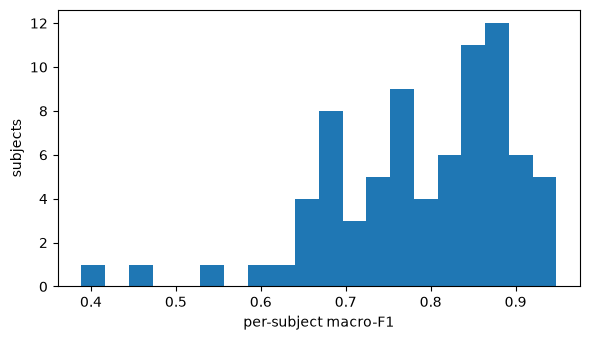

In [9]:
from sklearn.metrics import f1_score


def macro_f1(g):
    present = np.unique(g["stage"])
    return f1_score(g["stage"], g["pred"], labels=present, average="macro", zero_division=0)


by_subject = (
    pred.groupby("subject")
    .apply(
        lambda g: pd.Series(
            {
                "macro_f1": macro_f1(g),
                "epochs": len(g),
                "nights": g["night"].nunique(),
                **{f"share_{s}": (g["stage"] == i).mean() for i, s in enumerate(STAGES)},
            }
        ),
        include_groups=False,
    )
    .sort_values("macro_f1")
)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(by_subject["macro_f1"], bins=20)
ax.set_xlabel("per-subject macro-F1")
ax.set_ylabel("subjects")
fig.tight_layout()

by_subject["macro_f1"].describe().round(3)

In [10]:
pd.concat([by_subject.head(6), by_subject.tail(4)]).round(3)

,macro_f1,epochs,nights,share_W,share_LS,share_DS,share_R
subject,,,,,,,
SC457,0.389,2331.0,2.0,0.198,0.589,0.012,0.201
SC476,0.457,4326.0,2.0,0.668,0.227,0.006,0.099
SC470,0.543,3232.0,2.0,0.446,0.470,0.021,0.063
SC459,0.610,3071.0,2.0,0.445,0.336,0.084,0.134
SC437,0.633,2427.0,2.0,0.340,0.590,0.007,0.062
SC471,0.645,2654.0,2.0,0.332,0.571,0.002,0.095
SC413,0.921,1028.0,1.0,0.151,0.539,0.143,0.167
SC403,0.928,1863.0,2.0,0.148,0.532,0.101,0.219
SC414,0.935,1956.0,2.0,0.188,0.433,0.151,0.228
